# Exploratory Data Analysis

## Overview

This notebook performs Exploratory Data Analysis (EDA) on the preprocessed Telco Customer Churn dataset. The objective is to understand the characteristics of the data, identify relationships between features, discover important patterns, and generate business insights that support machine learning model development.

## Activities Performed

- Load the preprocessed dataset
- Perform dataset overview
- Conduct univariate analysis
- Conduct bivariate analysis
- Calculate correlation coefficients
- Generate correlation heatmap
- Analyze feature importance
- Derive business insights

**Assignment Mapping**

This notebook satisfies **Sub-Objective 1.4 – Exploratory Data Analysis**, which includes:

- Correlation analysis
- Feature relationships
- Feature importance
- Data visualization using charts and graphs
- Univariate analysis
- Bivariate analysis

In [1]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../data/processed/customer_churn_processed.csv")

print("Processed dataset loaded successfully.")

print(f"Dataset Shape: {df.shape}")

df.head()

Processed dataset loaded successfully.
Dataset Shape: (7043, 7073)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,-1.277445,-1.160323,-0.994242,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1,0,0.066327,-0.259629,-0.173244,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,-1.236724,-0.362660,-0.959674,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,0.514251,-0.746535,-0.194766,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0,-1.236724,0.197365,-0.940470,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1


## 2. Dataset Overview

This section provides a basic overview of the processed dataset, including dataset shape, column details, data types, and summary statistics.

Assignment Mapping: Sub-Objective 1.4 – Exploratory Data Analysis.

In [3]:
overview_summary = pd.DataFrame({
    "Item": [
        "Number of Rows",
        "Number of Columns",
        "Missing Values",
        "Duplicate Records"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

overview_summary

,Item,Value
0,Number of Rows,7043
1,Number of Columns,7073
2,Missing Values,0
3,Duplicate Records,0


In [4]:
# Save Dataset Overview Report

os.makedirs("../reports", exist_ok=True)

# Save CSV
overview_summary.to_csv(
    "../reports/dataset_overview_summary.csv",
    index=False
)

# Save PNG
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.axis("off")

table = ax.table(
    cellText=overview_summary.values,
    colLabels=overview_summary.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.savefig(
    "../reports/dataset_overview_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Dataset overview artifacts saved successfully.")
print("CSV : ../reports/dataset_overview_summary.csv")
print("PNG : ../reports/dataset_overview_summary.png")

Dataset overview artifacts saved successfully.
CSV : ../reports/dataset_overview_summary.csv
PNG : ../reports/dataset_overview_summary.png


## 3. Summary Statistics

This section summarizes the numerical features of the processed dataset, providing descriptive statistics such as count, mean, standard deviation, minimum, maximum, and quartile values.

Assignment Mapping: Sub-Objective 1.4 – Exploratory Data Analysis.

In [5]:
# Generate summary statistics
summary_statistics = df.describe().transpose()

# Display summary statistics
summary_statistics

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,1.621468e-01,0.368612,0.000000,0.000000,0.000000,0.000000,1.000000
tenure,7043.0,-1.916841e-17,1.000071,-1.318165,-0.951682,-0.137274,0.921455,1.613701
MonthlyCharges,7043.0,-6.204512e-17,1.000071,-1.545860,-0.972540,0.185733,0.833833,1.794352
TotalCharges,7043.0,-1.462852e-17,1.000071,-0.999120,-0.829846,-0.390463,0.664287,2.826743
customerID_0003-MKNFE,7043.0,1.419849e-04,0.011916,0.000000,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...
PaperlessBilling_Yes,7043.0,5.922192e-01,0.491457,0.000000,0.000000,1.000000,1.000000,1.000000
PaymentMethod_Credit card (automatic),7043.0,2.161011e-01,0.411613,0.000000,0.000000,0.000000,0.000000,1.000000
PaymentMethod_Electronic check,7043.0,3.357944e-01,0.472301,0.000000,0.000000,0.000000,1.000000,1.000000
PaymentMethod_Mailed check,7043.0,2.288797e-01,0.420141,0.000000,0.000000,0.000000,0.000000,1.000000


In [6]:
summary_statistics.to_csv(
    "../reports/summary_statistics.csv"
)

summary_statistics_preview = summary_statistics.head(12)

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis("off")

table = ax.table(
    cellText=summary_statistics_preview.round(2).values,
    rowLabels=summary_statistics_preview.index,
    colLabels=summary_statistics_preview.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.1, 1.3)

plt.savefig(
    "../reports/summary_statistics_preview.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Summary statistics artifacts saved successfully.")
print("CSV : ../reports/summary_statistics.csv")
print("PNG preview : ../reports/summary_statistics_preview.png")

Summary statistics artifacts saved successfully.
CSV : ../reports/summary_statistics.csv
PNG preview : ../reports/summary_statistics_preview.png


## 4. Univariate Analysis

Univariate analysis examines the distribution of individual features in the dataset. It helps understand customer characteristics, identify data distributions, and detect potential patterns related to customer churn.

The following visualizations are generated:

- Churn Distribution
- Gender Distribution
- Contract Type Distribution
- Internet Service Distribution
- Payment Method Distribution
- Tenure Distribution
- Monthly Charges Distribution

Assignment Mapping: Sub-Objective 1.4 – Exploratory Data Analysis.

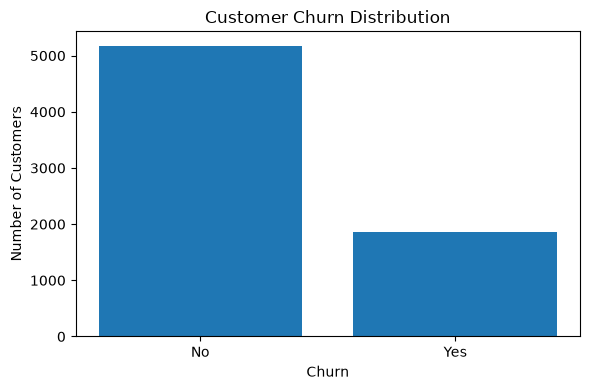

Churn distribution artifacts saved successfully.


In [7]:
# Churn Distribution

os.makedirs("../reports", exist_ok=True)

# Convert encoded churn values to labels
churn_counts = (
    df["Churn_Yes"]
    .map({0: "No", 1: "Yes"})
    .value_counts()
)

# Save CSV
churn_counts.rename_axis("Churn").reset_index(name="Count").to_csv(
    "../reports/churn_distribution.csv",
    index=False
)

# Plot
plt.figure(figsize=(6,4))

plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/churn_distribution.png",
    dpi=300
)

plt.show()

print("Churn distribution artifacts saved successfully.")

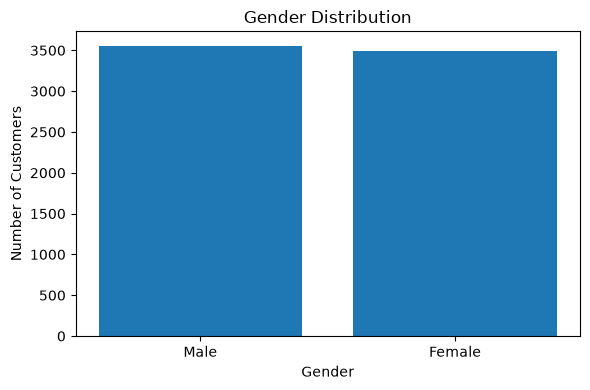

Gender distribution artifacts saved successfully.


In [8]:
# Gender Distribution

gender_counts = (
    df["gender_Male"]
    .map({0: "Female", 1: "Male"})
    .value_counts()
)

# Save CSV
gender_counts.rename_axis("Gender").reset_index(name="Count").to_csv(
    "../reports/gender_distribution.csv",
    index=False
)

# Plot
plt.figure(figsize=(6,4))

plt.bar(
    gender_counts.index,
    gender_counts.values
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/gender_distribution.png",
    dpi=300
)

plt.show()

print("Gender distribution artifacts saved successfully.")

In [9]:
def save_bar_chart_from_encoded_column(
    dataframe,
    column_name,
    label_mapping,
    csv_path,
    png_path,
    chart_title,
    x_label,
    y_label="Number of Customers"
):
    counts = (
        dataframe[column_name]
        .map(label_mapping)
        .value_counts()
    )

    counts.rename_axis(x_label).reset_index(name="Count").to_csv(
        csv_path,
        index=False
    )

    plt.figure(figsize=(7, 4))
    plt.bar(counts.index, counts.values)

    plt.title(chart_title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    plt.tight_layout()
    plt.savefig(png_path, dpi=300)
    plt.show()

    print(f"{chart_title} artifacts saved successfully.")
    print("CSV:", csv_path)
    print("PNG:", png_path)

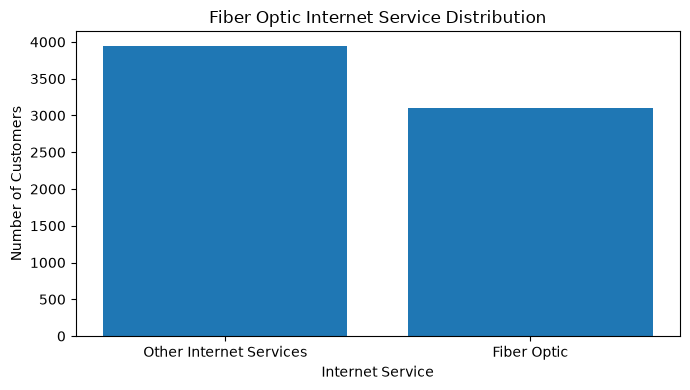

Fiber Optic Internet Service Distribution artifacts saved successfully.
CSV: ../reports/internet_service_distribution.csv
PNG: ../reports/internet_service_distribution.png


In [10]:
save_bar_chart_from_encoded_column(
    dataframe=df,
    column_name="InternetService_Fiber optic",
    label_mapping={
        0: "Other Internet Services",
        1: "Fiber Optic"
    },
    csv_path="../reports/internet_service_distribution.csv",
    png_path="../reports/internet_service_distribution.png",
    chart_title="Fiber Optic Internet Service Distribution",
    x_label="Internet Service"
)

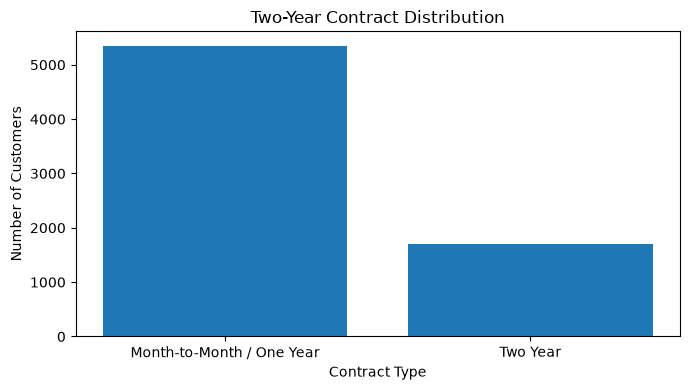

Two-Year Contract Distribution artifacts saved successfully.
CSV: ../reports/contract_type_distribution.csv
PNG: ../reports/contract_type_distribution.png


In [11]:
save_bar_chart_from_encoded_column(
    dataframe=df,
    column_name="Contract_Two year",
    label_mapping={
        0: "Month-to-Month / One Year",
        1: "Two Year"
    },
    csv_path="../reports/contract_type_distribution.csv",
    png_path="../reports/contract_type_distribution.png",
    chart_title="Two-Year Contract Distribution",
    x_label="Contract Type"
)

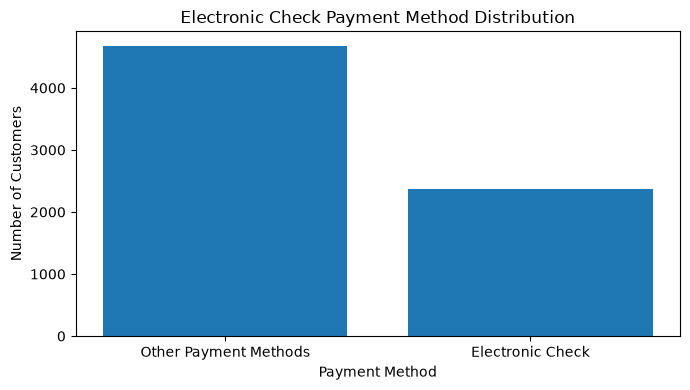

Electronic Check Payment Method Distribution artifacts saved successfully.
CSV: ../reports/payment_method_distribution.csv
PNG: ../reports/payment_method_distribution.png


In [12]:
save_bar_chart_from_encoded_column(
    dataframe=df,
    column_name="PaymentMethod_Electronic check",
    label_mapping={
        0: "Other Payment Methods",
        1: "Electronic Check"
    },
    csv_path="../reports/payment_method_distribution.csv",
    png_path="../reports/payment_method_distribution.png",
    chart_title="Electronic Check Payment Method Distribution",
    x_label="Payment Method"
)

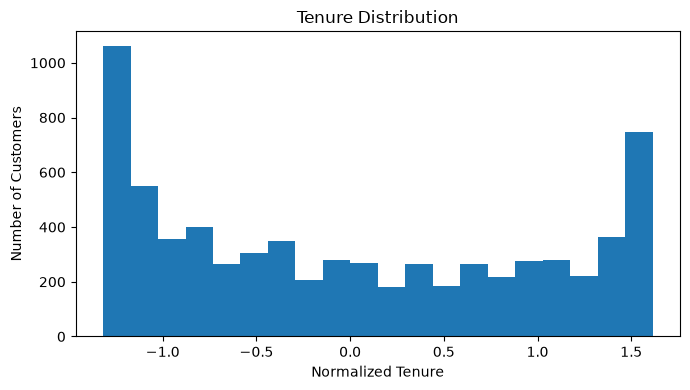

Tenure distribution artifacts saved successfully.


In [13]:
tenure_values = df["tenure"]

# Save CSV
tenure_values.to_frame(name="tenure").to_csv(
    "../reports/tenure_distribution.csv",
    index=False
)

# Plot histogram
plt.figure(figsize=(7, 4))

plt.hist(
    tenure_values,
    bins=20
)

plt.title("Tenure Distribution")
plt.xlabel("Normalized Tenure")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/tenure_distribution.png",
    dpi=300
)

plt.show()

print("Tenure distribution artifacts saved successfully.")

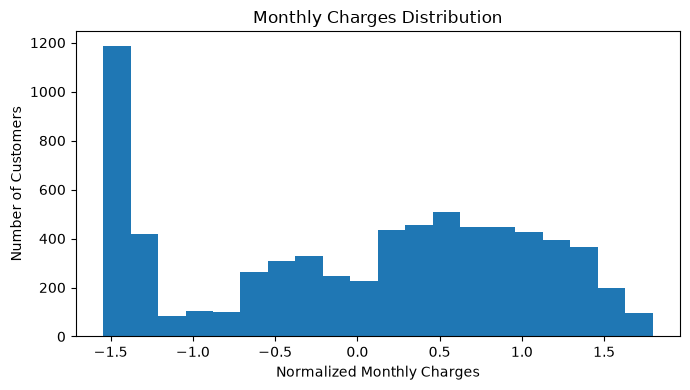

Monthly Charges distribution artifacts saved successfully.


In [14]:
monthly_charges = df["MonthlyCharges"]

# Save CSV
monthly_charges.to_frame(name="MonthlyCharges").to_csv(
    "../reports/monthly_charges_distribution.csv",
    index=False
)

# Plot histogram
plt.figure(figsize=(7, 4))

plt.hist(
    monthly_charges,
    bins=20
)

plt.title("Monthly Charges Distribution")
plt.xlabel("Normalized Monthly Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/monthly_charges_distribution.png",
    dpi=300
)

plt.show()

print("Monthly Charges distribution artifacts saved successfully.")

## 5. Bivariate Analysis

Bivariate analysis examines the relationship between the target variable and selected customer features. This helps identify which customer characteristics are associated with churn.

Assignment Mapping: Sub-Objective 1.4 – Exploratory Data Analysis.

In [15]:
def save_churn_rate_bar_chart(
    dataframe,
    feature_column,
    label_mapping,
    csv_path,
    png_path,
    chart_title,
    x_label
):
    temp_df = dataframe[[feature_column, "Churn_Yes"]].copy()
    temp_df[x_label] = temp_df[feature_column].map(label_mapping)

    churn_rate = (
        temp_df
        .groupby(x_label)["Churn_Yes"]
        .mean()
        .sort_values(ascending=False)
    )

    churn_rate_df = churn_rate.reset_index()
    churn_rate_df["Churn_Rate"] = churn_rate_df["Churn_Yes"] * 100
    churn_rate_df = churn_rate_df.drop(columns=["Churn_Yes"])

    churn_rate_df.to_csv(csv_path, index=False)

    plt.figure(figsize=(7, 4))
    plt.bar(churn_rate_df[x_label], churn_rate_df["Churn_Rate"])

    plt.title(chart_title)
    plt.xlabel(x_label)
    plt.ylabel("Churn Rate (%)")

    plt.tight_layout()
    plt.savefig(png_path, dpi=300)
    plt.show()

    print(f"{chart_title} artifacts saved successfully.")
    print("CSV:", csv_path)
    print("PNG:", png_path)

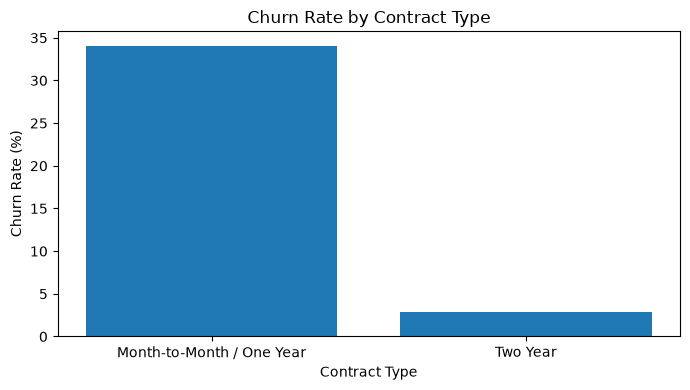

Churn Rate by Contract Type artifacts saved successfully.
CSV: ../reports/churn_rate_by_contract.csv
PNG: ../reports/churn_rate_by_contract.png


In [16]:
save_churn_rate_bar_chart(
    dataframe=df,
    feature_column="Contract_Two year",
    label_mapping={
        0: "Month-to-Month / One Year",
        1: "Two Year"
    },
    csv_path="../reports/churn_rate_by_contract.csv",
    png_path="../reports/churn_rate_by_contract.png",
    chart_title="Churn Rate by Contract Type",
    x_label="Contract Type"
)

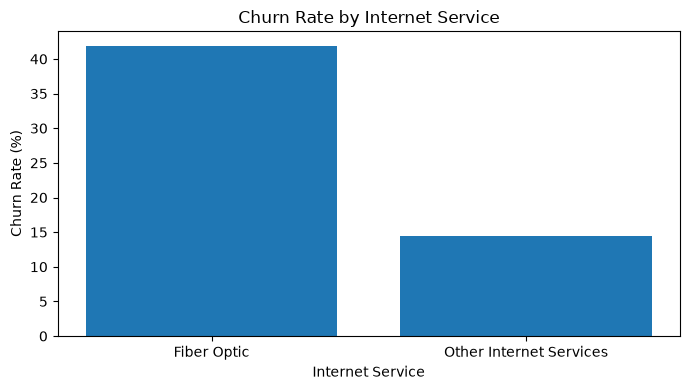

Churn Rate by Internet Service artifacts saved successfully.
CSV: ../reports/churn_rate_by_internet_service.csv
PNG: ../reports/churn_rate_by_internet_service.png


In [17]:
save_churn_rate_bar_chart(
    dataframe=df,
    feature_column="InternetService_Fiber optic",
    label_mapping={
        0: "Other Internet Services",
        1: "Fiber Optic"
    },
    csv_path="../reports/churn_rate_by_internet_service.csv",
    png_path="../reports/churn_rate_by_internet_service.png",
    chart_title="Churn Rate by Internet Service",
    x_label="Internet Service"
)

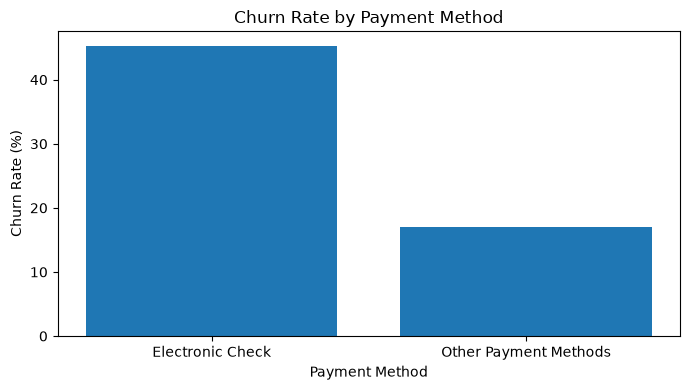

Churn Rate by Payment Method artifacts saved successfully.
CSV: ../reports/churn_rate_by_payment_method.csv
PNG: ../reports/churn_rate_by_payment_method.png


In [18]:
save_churn_rate_bar_chart(
    dataframe=df,
    feature_column="PaymentMethod_Electronic check",
    label_mapping={
        0: "Other Payment Methods",
        1: "Electronic Check"
    },
    csv_path="../reports/churn_rate_by_payment_method.csv",
    png_path="../reports/churn_rate_by_payment_method.png",
    chart_title="Churn Rate by Payment Method",
    x_label="Payment Method"
)

## 6. Correlation Analysis

Correlation analysis is used to identify the strength and direction of relationships between numerical features and the churn target variable.

Assignment Mapping: Sub-Objective 1.4 – Exploratory Data Analysis.

In [19]:
selected_correlation_columns = [
    "Churn_Yes",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "gender_Male",
    "SeniorCitizen",
    "Partner_Yes",
    "Dependents_Yes",
    "PhoneService_Yes",
    "InternetService_Fiber optic",
    "Contract_Two year",
    "PaperlessBilling_Yes",
    "PaymentMethod_Electronic check"
]

available_columns = [
    col for col in selected_correlation_columns
    if col in df.columns
]

correlation_with_churn = (
    df[available_columns]
    .corr()["Churn_Yes"]
    .sort_values(ascending=False)
)

correlation_with_churn_df = correlation_with_churn.reset_index()
correlation_with_churn_df.columns = ["Feature", "Correlation_With_Churn"]

correlation_with_churn_df.to_csv(
    "../reports/correlation_with_churn.csv",
    index=False
)

correlation_with_churn_df

,Feature,Correlation_With_Churn
0,Churn_Yes,1.000000
1,InternetService_Fiber optic,0.308020
2,PaymentMethod_Electronic check,0.301919
3,MonthlyCharges,0.193356
4,PaperlessBilling_Yes,0.191825
5,SeniorCitizen,0.150889
6,PhoneService_Yes,0.011942
7,gender_Male,-0.008612
8,Partner_Yes,-0.150448
9,Dependents_Yes,-0.164221


## 7. Correlation Heatmap

A correlation heatmap provides a visual representation of the relationships between important numerical features and the target variable. It helps identify positively and negatively correlated features that may influence customer churn.

Assignment Mapping: Sub-Objective 1.4 – Exploratory Data Analysis.

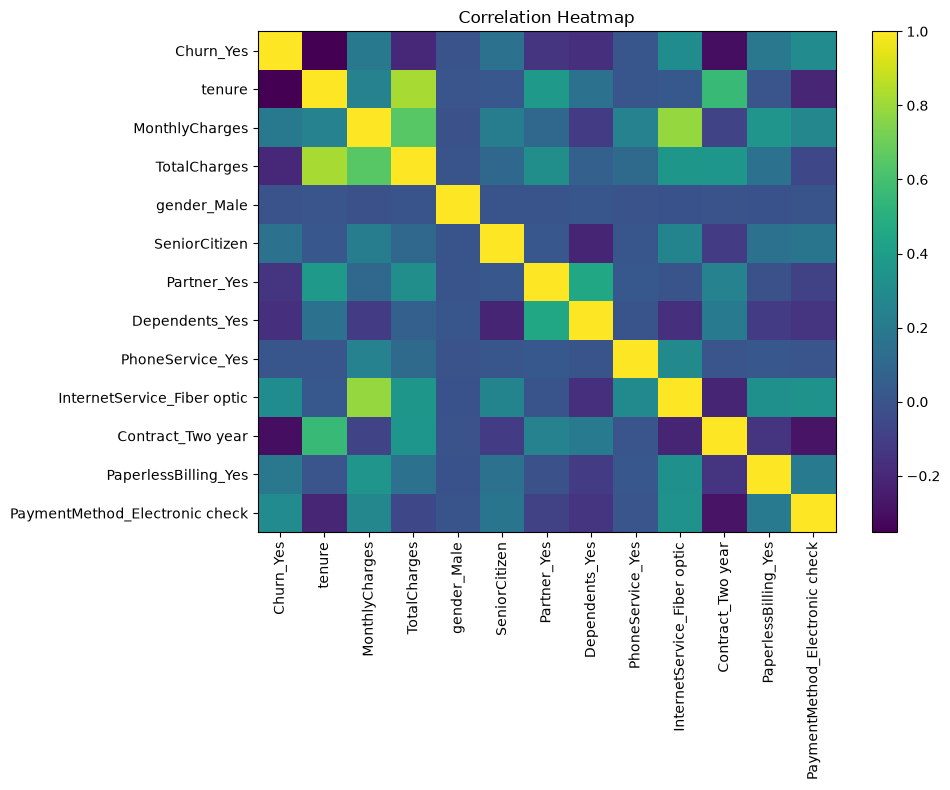

Correlation heatmap saved successfully.


In [20]:
# Correlation Heatmap

heatmap_correlation = df[available_columns].corr()

plt.figure(figsize=(10, 8))

plt.imshow(heatmap_correlation, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(heatmap_correlation.columns)),
    heatmap_correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(heatmap_correlation.columns)),
    heatmap_correlation.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../reports/correlation_heatmap.png",
    dpi=300
)

plt.show()

print("Correlation heatmap saved successfully.")

## 8. Feature Importance

Feature importance analysis helps identify which features contribute most to predicting customer churn. A Random Forest model is used here only for exploratory analysis to estimate the relative importance of selected features.

Assignment Mapping: Sub-Objective 1.4 – Exploratory Data Analysis.

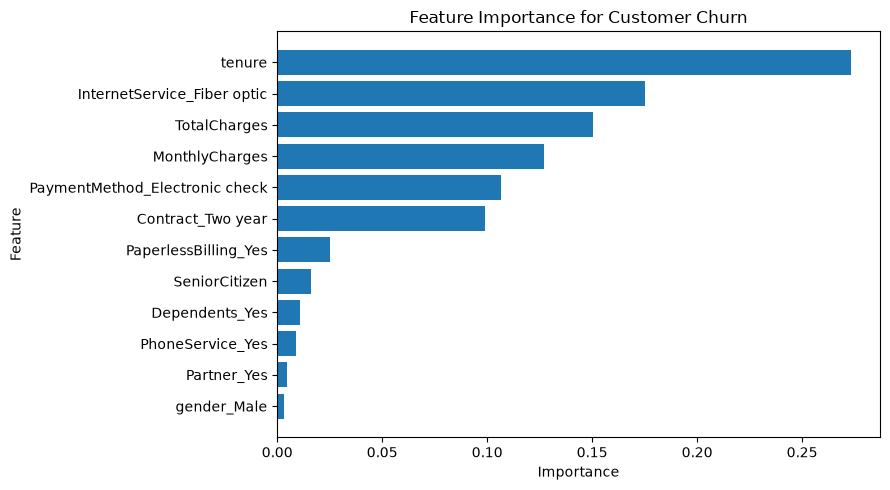

Feature importance artifacts saved successfully.
CSV : ../reports/feature_importance_selected.csv
PNG : ../reports/feature_importance_selected.png


In [22]:
from sklearn.ensemble import RandomForestClassifier

selected_importance_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "gender_Male",
    "SeniorCitizen",
    "Partner_Yes",
    "Dependents_Yes",
    "PhoneService_Yes",
    "InternetService_Fiber optic",
    "Contract_Two year",
    "PaperlessBilling_Yes",
    "PaymentMethod_Electronic check"
]

available_importance_columns = [
    col for col in selected_importance_columns
    if col in df.columns
]

X_importance = df[available_importance_columns]
y_importance = df["Churn_Yes"]

rf_importance_model = RandomForestClassifier(
    n_estimators=30,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

rf_importance_model.fit(X_importance, y_importance)

feature_importance_df = pd.DataFrame({
    "Feature": available_importance_columns,
    "Importance": rf_importance_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_df.to_csv(
    "../reports/feature_importance_selected.csv",
    index=False
)

plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance for Customer Churn")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../reports/feature_importance_selected.png",
    dpi=300
)

plt.show()

print("Feature importance artifacts saved successfully.")
print("CSV : ../reports/feature_importance_selected.csv")
print("PNG : ../reports/feature_importance_selected.png")

## 9. Business Insights

Based on the exploratory data analysis, the following key business insights were identified:

- The customer churn distribution indicates that a significant proportion of customers have discontinued the service.
- Customers using Fiber Optic internet services exhibit different churn behavior compared to customers using other internet services.
- Customers with Two-Year contracts generally demonstrate lower churn rates than customers with shorter contract durations.
- Electronic Check is a commonly used payment method among customers and may be associated with higher churn.
- Monthly Charges and Total Charges show measurable relationships with customer churn.
- Feature importance analysis indicates that contract type, tenure, monthly charges, and internet service are among the most influential predictors of customer churn.

These insights will guide the machine learning model development in the next stage of the project.